In [186]:
from collections import defaultdict
from dataclasses import dataclass
from typing import TypeAlias, Callable
from itertools import combinations

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from sklearn.datasets import load_iris
from IPython.display import Image, display

from utils import create_animation_plot

In [187]:
SEED = 42

In [188]:
# Fazendo a tipagem dos pesos e de um Tensor
Tensor: TypeAlias = np.ndarray

In [189]:
# Pegando o conjunto de dados
X, y = load_iris(return_X_y=True)

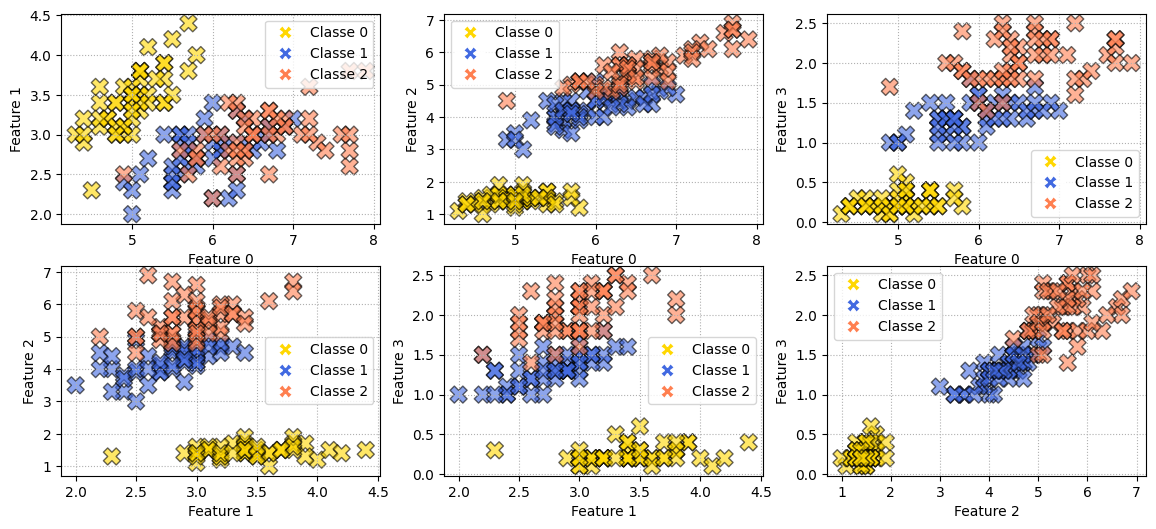

In [190]:
# definindo o color map
cmap_ = ListedColormap(['#FFD700', '#4169E1', '#FF7F50'])

# Plotagem para ver os dados
legend_elements = [
    Line2D(
        [0], [0], marker='X', color='w', markerfacecolor='#FFD700', 
        markersize=10, label='Classe 0'
    ),
    Line2D(
        [0], [0], marker='X', color='w', markerfacecolor='#4169E1', 
        markersize=10, label='Classe 1'
    ),
    Line2D(
        [0], [0], marker='X', color='w', markerfacecolor='#FF7F50', 
        markersize=10, label='Classe 2'
    )
]
features_pairs = list(combinations(range(X.shape[1]), 2))
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
axes = axes.flatten()
for ax, (i, j) in zip(axes, features_pairs):
    ax.scatter(
        X[:, i],
        X[:, j],
        c=y,
        marker='X',
        cmap=cmap_,
        s=150,
        alpha=0.6,
        edgecolor='k'
    )

    ax.set_xlabel(f"Feature {i}")
    ax.set_ylabel(f"Feature {j}")
    ax.grid(True, linestyle=':')
    ax.legend(handles=legend_elements)

In [191]:
LR = 1e-1
EPOCHS = 30

IN_FEATURES = X.shape[1]
OUT_LABELS = len(set(y))

In [192]:
@dataclass
class Neuron:
    in_: int
    W: Tensor | None = None
    b: Tensor | None = None

    def __post_init__(self):
        if self.W is None:
            self.W = np.random.randn(self.in_)
        if self.b is None:
            self.b = float(np.random.randn())

@dataclass
class Layer:
    neurons: list[Neuron]

@dataclass
class MLP:
    layers: dict[str, Layer]

In [193]:
input_layer = Layer(
    [Neuron(in_=IN_FEATURES) for _ in range(4)]
)

hidden_layer = Layer(
    neurons=[Neuron(in_=4) for _ in range(8)]
)

output_layer = Layer(
    neurons=[Neuron(in_=8) for _ in range(OUT_LABELS)]
)

In [230]:
layers = {
    'input': input_layer,
    'hidden': hidden_layer,
    'output': output_layer
}

In [231]:
mlp = MLP(layers=layers)

In [232]:
mlp

MLP(layers={'input': Layer(neurons=[Neuron(in_=4), Neuron(in_=4), Neuron(in_=4), Neuron(in_=4)]), 'hidden': Layer(neurons=[Neuron(in_=4), Neuron(in_=4), Neuron(in_=4), Neuron(in_=4), Neuron(in_=4), Neuron(in_=4), Neuron(in_=4), Neuron(in_=4)]), 'output': Layer(neurons=[Neuron(in_=8), Neuron(in_=8), Neuron(in_=8)])})

In [197]:
def relu(z: Tensor) -> Tensor:
    return np.where(z > 0, z, 0)

In [220]:
def softmax(x: Tensor) -> Tensor:
    x_shifted = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x_shifted)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

In [227]:
def neuron_forward(neuron: Neuron, X: Tensor) -> Tensor:
    return X @ neuron.W + neuron.b

def layer_forward(layer: Layer, X: Tensor) -> Tensor:
    outputs = [neuron_forward(n, X) for n in layer.neurons]
    return np.stack(outputs, axis=1)

def forward(net: MLP, x: Tensor) -> Tensor:
    for layer_id, layer in net.layers.items():
        x = layer_forward(layer, x)
        if layer_id != 'output':
            x = relu(x)
        else:
            x = softmax(x)
    return x

In [219]:
# nossa rede
softmax(
    layer_forward(
        output_layer,
        relu(
            layer_forward(
                hidden_layer,
                relu(
                    layer_forward(input_layer, X[:10])
                )
            )
        )
    )
)

array([[1.9941e-23, 4.9058e-01, 5.0942e-01],
       [1.3518e-21, 4.8444e-01, 5.1556e-01],
       [3.3485e-22, 2.8052e-01, 7.1948e-01],
       [8.0987e-23, 1.3704e-01, 8.6296e-01],
       [6.2270e-24, 3.4612e-01, 6.5388e-01],
       [9.4508e-27, 2.5152e-01, 7.4848e-01],
       [4.7679e-24, 8.4157e-02, 9.1584e-01],
       [1.5385e-23, 3.5012e-01, 6.4988e-01],
       [8.2040e-22, 1.1407e-01, 8.8593e-01],
       [4.6436e-22, 4.5385e-01, 5.4615e-01]])

In [228]:
forward(mlp, X[:5])

array([[1.9941e-23, 4.9058e-01, 5.0942e-01],
       [1.3518e-21, 4.8444e-01, 5.1556e-01],
       [3.3485e-22, 2.8052e-01, 7.1948e-01],
       [8.0987e-23, 1.3704e-01, 8.6296e-01],
       [6.2270e-24, 3.4612e-01, 6.5388e-01]])

In [229]:
# tirando a prova que soma 1 na linha
forward(mlp, X[:5]).sum(axis=1)

array([1., 1., 1., 1., 1.])

In [ ]:
# CrossEntropy pois dL/dz é simples
def loss_fn() -> float:
    pass